In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
nav_history = pd.read_csv("../data/raw/02_nav_history.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

# Convert date columns
nav_history["date"] = pd.to_datetime(nav_history["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

print("NAV History Shape:", nav_history.shape)
print("Benchmark Shape:", benchmark.shape)

nav_history.head()

NAV History Shape: (46000, 3)
Benchmark Shape: (8050, 3)


,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [40]:
# Daily Returns Calculation

nav_history = nav_history.sort_values(["amfi_code", "date"])

nav_history["daily_return"] = (
    nav_history.groupby("amfi_code")["nav"]
    .pct_change()
)

nav_history.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [41]:
# CAGR (1Y, 3Y, 5Y) Comparison Table

latest_date = nav_history["date"].max()

cagr_table = []

for fund in nav_history["amfi_code"].unique():

    fund_df = nav_history[nav_history["amfi_code"] == fund].sort_values("date")

    latest_nav = fund_df.iloc[-1]["nav"]

    row = {"amfi_code": fund}

    for year in [1, 3, 5]:

        start_date = latest_date - pd.DateOffset(years=year)

        temp = fund_df[fund_df["date"] >= start_date]

        if len(temp) > 1:

            start_nav = temp.iloc[0]["nav"]

            cagr = ((latest_nav / start_nav) ** (1 / year) - 1) * 100

            row[f"CAGR_{year}Y"] = round(cagr, 2)

        else:

            row[f"CAGR_{year}Y"] = None

    cagr_table.append(row)

cagr_table = pd.DataFrame(cagr_table)

cagr_table

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-2.22,1.29,2.32
1,100025,3.70,3.92,3.91
2,100033,53.23,32.44,26.07
3,101206,47.92,28.97,20.44
4,101207,-23.99,-4.15,6.95
5,101208,7.24,6.32,5.71
6,102885,20.21,19.67,15.88
7,102886,-16.80,-0.77,1.03
8,102887,13.58,25.56,14.68
9,118632,33.98,22.65,20.88


In [42]:
# Sharpe Ratio Calculation

risk_free_rate = 0.065

sharpe_list = []

for fund in nav_history["amfi_code"].unique():

    fund_data = nav_history[nav_history["amfi_code"] == fund].copy()

    returns = fund_data["daily_return"].dropna()

    if len(returns) > 1:

        annual_return = returns.mean() * 252

        annual_std = returns.std() * np.sqrt(252)

        sharpe = (annual_return - risk_free_rate) / annual_std

    else:

        sharpe = np.nan

    sharpe_list.append({
        "amfi_code": fund,
        "Sharpe_Ratio": round(sharpe, 4)
    })

sharpe_df = pd.DataFrame(sharpe_list)

sharpe_df.sort_values("Sharpe_Ratio", ascending=False).head(10)

,amfi_code,Sharpe_Ratio
34,148567,1.4483
30,120843,1.3067
36,148569,1.2349
19,119551,1.2083
25,120505,1.1801
38,149323,1.1321
2,100033,1.0937
9,118632,1.0817
3,101206,1.0272
24,120504,1.0265


In [43]:
# Sortino Ratio Calculation

risk_free_rate = 0.065

sortino_results = []

for fund in nav_history["amfi_code"].unique():

    fund_data = nav_history[nav_history["amfi_code"] == fund]

    returns = fund_data["daily_return"].dropna()

    downside_returns = returns[returns < 0]

    if len(returns) > 1 and len(downside_returns) > 1:

        annual_return = returns.mean() * 252
        downside_std = downside_returns.std() * np.sqrt(252)

        sortino_ratio = (annual_return - risk_free_rate) / downside_std

    else:
        sortino_ratio = np.nan

    sortino_results.append({
        "amfi_code": fund,
        "Sortino_Ratio": round(sortino_ratio, 4)
    })

sortino_df = pd.DataFrame(sortino_results)

sortino_df = sortino_df.sort_values(
    by="Sortino_Ratio",
    ascending=False
)

sortino_df.head(10)

,amfi_code,Sortino_Ratio
34,148567,2.3856
30,120843,2.3643
36,148569,2.1469
19,119551,2.1403
25,120505,2.0294
38,149323,1.8751
9,118632,1.8501
2,100033,1.8291
24,120504,1.8053
3,101206,1.7996


In [44]:
from scipy.stats import linregress
import pandas as pd

# Prepare benchmark (NIFTY100)
benchmark_data = benchmark[benchmark["index_name"] == "NIFTY100"].copy()
benchmark_data = benchmark_data.sort_values("date")

benchmark_data["benchmark_return"] = benchmark_data["close_value"].pct_change()

benchmark_data = benchmark_data[["date", "benchmark_return"]].dropna()

alpha_beta_list = []

for fund in nav_history["amfi_code"].unique():

    fund_data = nav_history[nav_history["amfi_code"] == fund].copy()
    fund_data = fund_data.sort_values("date")

    fund_data = fund_data[["date", "daily_return"]].dropna()

    merged = pd.merge(
        fund_data,
        benchmark_data,
        on="date",
        how="inner"
    ).dropna()

    if len(merged) < 30:
        continue

    beta, alpha, r_value, p_value, std_err = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha_beta_list.append({
        "amfi_code": fund,
        "Alpha": round(alpha * 252, 4),
        "Beta": round(beta, 4)
    })

alpha_beta_df = pd.DataFrame(alpha_beta_list)

alpha_beta_df.head(10)

,amfi_code,Alpha,Beta
0,100016,0.0375,-0.0583
1,100025,0.0428,0.0012
2,100033,0.2720,0.0051
3,101206,0.2140,0.0211
4,101207,0.1090,-0.0653
5,101208,0.0609,0.0003
6,102885,0.1705,-0.0195
7,102886,0.0290,-0.0421
8,102887,0.1621,0.0167
9,118632,0.2183,-0.0084


In [45]:
# ============================
# Task 6 - Maximum Drawdown
# ============================

mdd_list = []

for fund in nav_history["amfi_code"].unique():

    fund_data = nav_history[nav_history["amfi_code"] == fund].copy()
    fund_data = fund_data.sort_values("date")

    fund_data["running_max"] = fund_data["nav"].cummax()

    fund_data["drawdown"] = (fund_data["nav"] / fund_data["running_max"]) - 1

    max_drawdown = fund_data["drawdown"].min()

    worst_date = fund_data.loc[
        fund_data["drawdown"].idxmin(),
        "date"
    ]

    mdd_list.append({
        "amfi_code": fund,
        "Maximum_Drawdown": round(max_drawdown, 4),
        "Worst_Drawdown_Date": worst_date
    })

mdd_df = pd.DataFrame(mdd_list)

mdd_df.head(10)

,amfi_code,Maximum_Drawdown,Worst_Drawdown_Date
0,100016,-0.2473,2022-09-15
1,100025,-0.0431,2023-07-28
2,100033,-0.1622,2022-05-12
3,101206,-0.1129,2023-07-05
4,101207,-0.3545,2026-05-11
5,101208,-0.0016,2023-09-12
6,102885,-0.1086,2022-03-29
7,102886,-0.2800,2026-04-27
8,102887,-0.2154,2022-07-04
9,118632,-0.1741,2024-07-19


In [46]:
# ============================
# Task 7 - Fund Scorecard (0-100)
# ============================

# Merge required metrics
scorecard = cagr_3yr_df.merge(sharpe_df, on="amfi_code")
scorecard = scorecard.merge(alpha_beta_df[["amfi_code", "Alpha"]], on="amfi_code")
scorecard = scorecard.merge(
    mdd_df[["amfi_code", "Maximum_Drawdown"]],
    on="amfi_code"
)

# Rank metrics
scorecard["Return_Rank"] = scorecard["CAGR_3Y"].rank(ascending=False)
scorecard["Sharpe_Rank"] = scorecard["Sharpe_Ratio"].rank(ascending=False)
scorecard["Alpha_Rank"] = scorecard["Alpha"].rank(ascending=False)

# Lower drawdown is better
scorecard["Drawdown_Rank"] = scorecard["Maximum_Drawdown"].rank(ascending=True)

# Temporary expense ratio rank (replace later if available)
scorecard["Expense_Rank"] = 1

# Composite Score
scorecard["Fund_Score"] = (
    30 * (1 / scorecard["Return_Rank"]) +
    25 * (1 / scorecard["Sharpe_Rank"]) +
    20 * (1 / scorecard["Alpha_Rank"]) +
    15 * (1 / scorecard["Expense_Rank"]) +
    10 * (1 / scorecard["Drawdown_Rank"])
)

# Scale to 0-100
scorecard["Fund_Score"] = (
    scorecard["Fund_Score"] /
    scorecard["Fund_Score"].max()
) * 100

scorecard = scorecard.sort_values(
    "Fund_Score",
    ascending=False
)

scorecard.head(10)

,amfi_code,CAGR_3Y,Sharpe_Ratio,Alpha,Maximum_Drawdown,Return_Rank,Sharpe_Rank,Alpha_Rank,Drawdown_Rank,Expense_Rank,Fund_Score
25,120505,32.83,1.1801,0.2926,-0.1819,1.0,5.0,3.0,16.0,1,100.000000
21,119598,32.42,0.9453,0.3034,-0.2871,2.0,14.0,1.0,5.0,1,93.880519
34,148567,30.97,1.4483,0.2698,-0.1127,5.0,1.0,7.0,33.0,1,85.806848
39,149324,32.29,0.9498,0.3006,-0.3117,3.0,13.0,2.0,4.0,1,68.811189
30,120843,30.91,1.3067,0.2733,-0.1297,6.0,2.0,5.0,28.0,1,64.332468
36,148569,31.95,1.2349,0.2827,-0.1640,4.0,3.0,4.0,20.0,1,63.418182
22,119599,2.05,-0.0572,0.0488,-0.5257,38.0,32.0,36.0,1.0,1,47.347687
19,119551,25.80,1.2083,0.2320,-0.1501,10.0,4.0,10.0,24.0,1,46.545455
2,100033,30.12,1.0937,0.2720,-0.1622,7.0,7.0,6.0,21.0,1,46.545455
38,149323,29.58,1.1321,0.2660,-0.1725,8.0,6.0,8.0,19.0,1,45.282297


In [52]:
scorecard.to_csv("fund_scorecard.csv", index=False)

In [53]:
alpha_beta_df.to_csv("alpha_beta.csv", index=False)

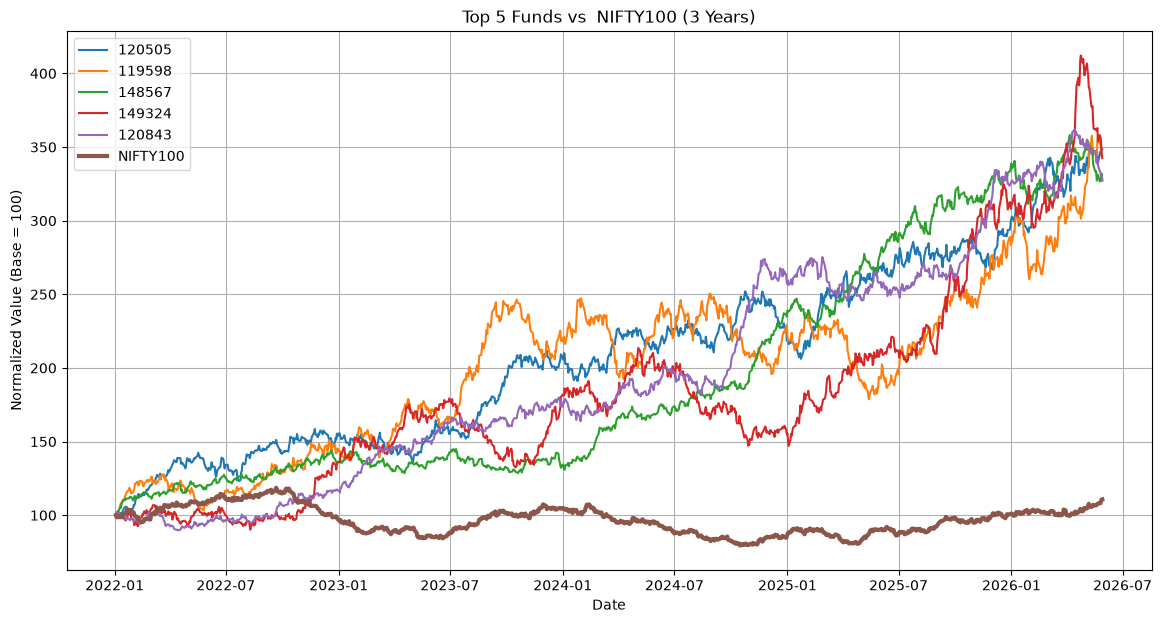

Tracking Error
Fund 120505: 0.2320
Fund 119598: 0.2839
Fund 148567: 0.1897
Fund 149324: 0.2792
Fund 120843: 0.2064


<Figure size 640x480 with 0 Axes>

In [55]:
import matplotlib.pyplot as plt
import numpy as np



benchmark =benchmark.sort_values(["index_name", "date"])
benchmark["benchmark_return"] = benchmark.groupby("index_name")["close_value"].pct_change()

# Top 5 funds from scorecard
top5 = scorecard.head(5)["amfi_code"].tolist()

plt.figure(figsize=(14,7))

# Plot Top 5 Funds (Normalized NAV)
for fund in top5:
    fund_data = nav_history[nav_history["amfi_code"] == fund].copy()
    fund_data = fund_data.sort_values("date")

    fund_data["Normalized"] = (
        fund_data["nav"] / fund_data["nav"].iloc[0]
    ) * 100

    plt.plot(
        fund_data["date"],
        fund_data["Normalized"],
        label=str(fund)
    )



# Plot NIFTY100
nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].copy()
nifty100 = nifty100.sort_values("date")

nifty100["Normalized"] = (
    nifty100["close_value"] / nifty100["close_value"].iloc[0]
) * 100

plt.plot(
    nifty100["date"],
    nifty100["Normalized"],
    linewidth=3,
    label="NIFTY100"
)

plt.title("Top 5 Funds vs  NIFTY100 (3 Years)")
plt.xlabel("Date")
plt.ylabel("Normalized Value (Base = 100)")
plt.legend()
plt.grid(True)

plt.savefig("../reports/benchmark_comparison.png",dpi=300,
bbox_inches='tight')
plt.show()



print("Tracking Error")

for fund in top5:
    fund_return = nav_history[nav_history["amfi_code"] == fund][["date","daily_return"]]

    merged = pd.merge(
        fund_return,
        benchmark[benchmark["index_name"]=="NIFTY100"][["date","benchmark_return"]],
        on="date"
    ).dropna()

    tracking_error = (
        (merged["daily_return"] - merged["benchmark_return"]).std()
        * np.sqrt(252)
    )

    print(f"Fund {fund}: {tracking_error:.4f}")
    plt.savefig("benchmark_comparison.png",dpi=300,
    bbox_inches='tight')
